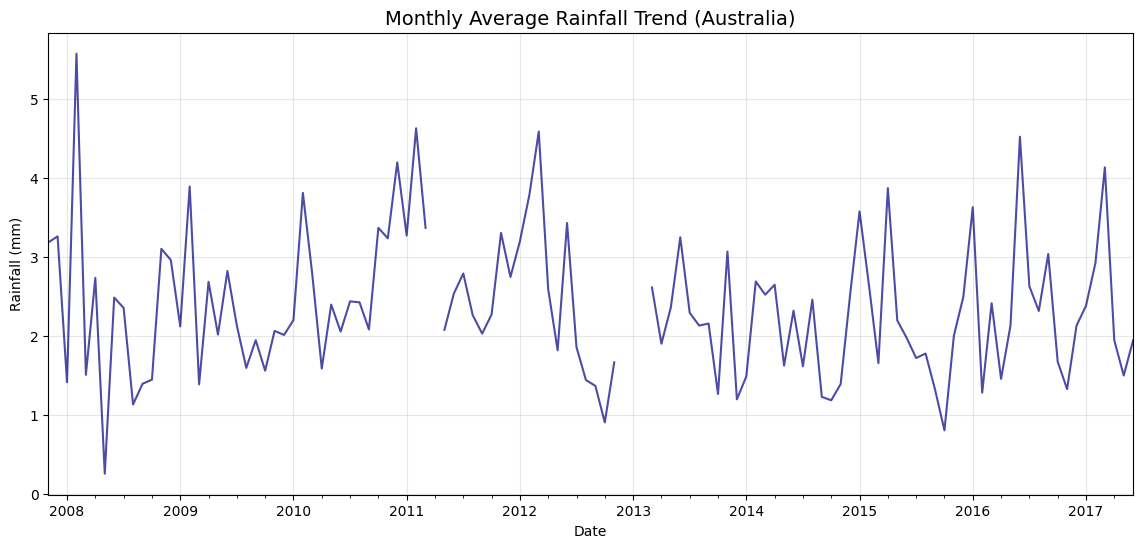

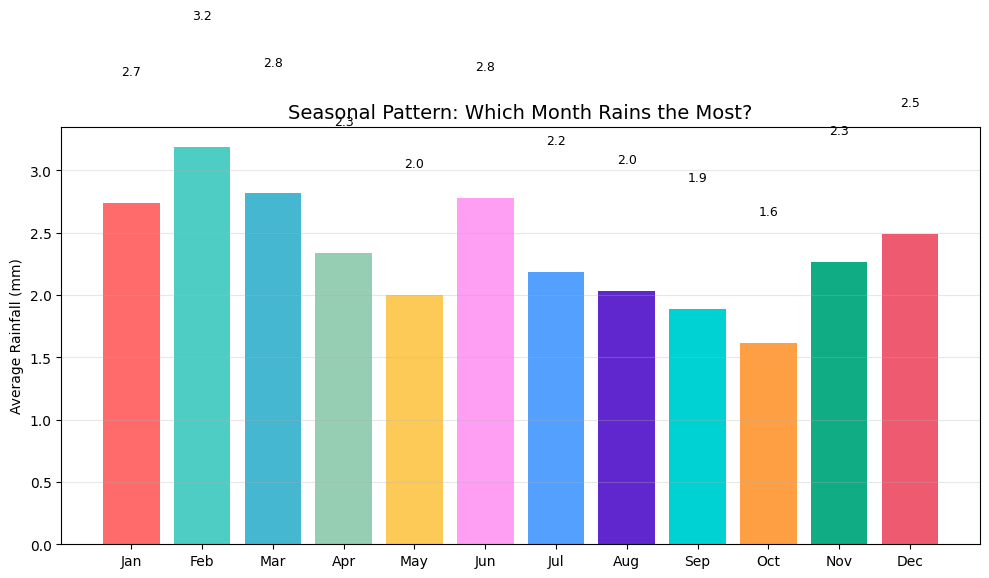

=== 季节性洞察 ===
降雨最多的月份：2月（3.2mm）
降雨最少的月份：10月（1.6mm）
波动最大（天气最不稳定）：2月


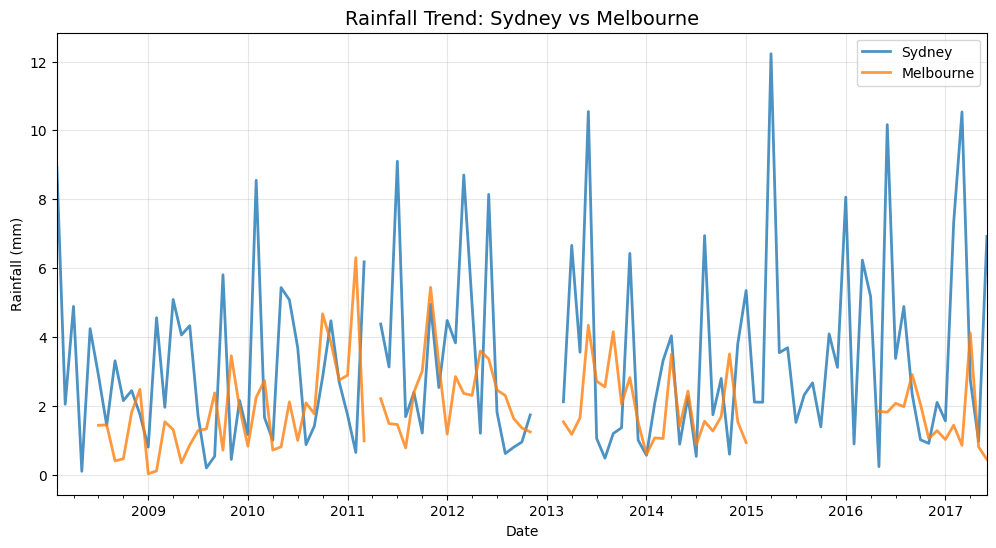

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 加载并处理时间列
data = pd.read_csv('weatherAUS.csv')
data['Date'] = pd.to_datetime(data['Date'])  # 字符串转时间格式
data = data.set_index('Date')  # 设时间为索引，方便resample

# 按月重采样：看长期趋势（全国平均）
monthly_rain = data['Rainfall'].resample('ME').mean()

plt.figure(figsize=(14, 6))
monthly_rain.plot(color='navy', alpha=0.7, linewidth=1.5)
plt.title('Monthly Average Rainfall Trend (Australia)', fontsize=14)
plt.ylabel('Rainfall (mm)')
plt.grid(True, alpha=0.3)
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# 季节性分析
data['Month'] = data.index.month  # 提取月份
seasonal_stats = data.groupby('Month')['Rainfall'].agg(['mean', 'std', 'max'])

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_stats.index, seasonal_stats['mean'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3',
                      '#54A0FF', '#5F27CD', '#00D2D3', '#FF9F43', '#10AC84', '#EE5A6F'])
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Average Rainfall (mm)')
plt.title('Seasonal Pattern: Which Month Rains the Most?', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# 添加数值标签
for i, v in enumerate(seasonal_stats['mean'], 1):
    plt.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('seasonal_pattern.png', dpi=150)
plt.show()

print("=== 季节性洞察 ===")
max_month = seasonal_stats['mean'].idxmax()
min_month = seasonal_stats['mean'].idxmin()
print(f"降雨最多的月份：{max_month}月（{seasonal_stats.loc[max_month, 'mean']:.1f}mm）")
print(f"降雨最少的月份：{min_month}月（{seasonal_stats.loc[min_month, 'mean']:.1f}mm）")
print(f"波动最大（天气最不稳定）：{seasonal_stats['std'].idxmax()}月")

# 特定城市时序对比（选2个对比明显的城市）
plt.figure(figsize=(12, 6))
cities = ['Sydney', 'Melbourne']  # 悉尼vs墨尔本
for city in cities:
    city_data = data[data['Location'] == city]
    monthly_city = city_data['Rainfall'].resample('ME').mean()
    monthly_city.plot(label=city, alpha=0.8, linewidth=2)

plt.title('Rainfall Trend: Sydney vs Melbourne', fontsize=14)
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('city_comparison_timeseries.png', dpi=150)
plt.show()